# Modèle de régression logistique

### Objectif, regrouper des zones similaires pour faciliter l'apport de solution de lutte contre le réchauffement climatique

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score

import joblib

In [2]:
# Import dataset
df = pd.read_csv('Dataset_LST_Massive_20k.csv')
df.head()

,Region_Type,Latitude,Longitude,Altitude_m,Day_of_year,Ndvi,Albedo,Cloud_cover_pct,Humidity_pct,Insolation_wm2,Lst_celsius
0,Dense_Urban_Temperate,48.8722,2.2984,68,0,0.0384,0.0970,20.78,50,200,10.23
1,Dense_Urban_Temperate,48.8802,2.3543,62,0,0.0196,0.0926,41.81,50,200,9.30
2,Dense_Urban_Temperate,48.8444,2.3000,43,0,0.0535,0.1158,20.33,50,200,10.36
3,Dense_Urban_Temperate,48.8535,2.3226,40,0,0.0757,0.1049,34.26,50,200,9.87
4,Dense_Urban_Temperate,48.8202,2.3462,64,0,0.1615,0.0870,39.36,50,200,8.06


In [3]:
df['Region_Type'].unique()

array(['Dense_Urban_Temperate', 'Subtropical_Urban_Canopy',
       'Hyper_Arid_Desert_Floor', 'Arid_Sandy_Desert',
       'Tropical_Rainforest_Canopy', 'Equatorial_Wetland_Basin',
       'Continental_Boreal_Taiga', 'High_Altitude_Alpine',
       'Polar_Ice_Sheet', 'Polar_Coastal_Desert',
       'Intensive_Agricultural_Plain', 'Coastal_Oceanic_Forest'],
      dtype=object)

In [4]:
# éléments vides, max, min (describe)
df.describe()

,Latitude,Longitude,Altitude_m,Day_of_year,Ndvi,Albedo,Cloud_cover_pct,Humidity_pct,Insolation_wm2,Lst_celsius
count,16779.000000,16779.000000,16779.000000,16779.000000,16779.000000,16779.000000,16779.00000,16779.0,16779.0,16779.000000
mean,21.559065,18.845094,706.484832,166.715895,0.315781,0.186802,28.52455,50.0,200.0,17.153472
std,35.273400,81.684270,1269.178550,105.160231,0.296922,0.244142,15.21091,0.0,0.0,23.497670
min,-77.336800,-99.841700,0.000000,0.000000,-0.182900,0.008700,2.00000,50.0,200.0,-58.430000
25%,-2.362500,-62.829900,33.000000,60.000000,0.072500,0.046600,15.41500,50.0,200.0,9.325000
50%,27.800900,11.641300,167.000000,152.000000,0.224800,0.091000,28.60000,50.0,200.0,25.910000
75%,48.853500,98.017800,602.000000,273.000000,0.560100,0.200000,41.66000,50.0,200.0,30.960000
max,73.472600,167.018400,6491.000000,335.000000,0.940000,0.996000,55.00000,50.0,200.0,57.460000


In [6]:
print(df.shape)

print("\nValeurs manquantes :")
print(df.isna().sum())

print("\nClasses :")
print(df["Region_Type"].value_counts())

(16779, 11)

Valeurs manquantes :
Region_Type        0
Latitude           0
Longitude          0
Altitude_m         0
Day_of_year        0
Ndvi               0
Albedo             0
Cloud_cover_pct    0
Humidity_pct       0
Insolation_wm2     0
Lst_celsius        0
dtype: int64

Classes :
Region_Type
Hyper_Arid_Desert_Floor         1584
Arid_Sandy_Desert               1584
Continental_Boreal_Taiga        1584
Polar_Ice_Sheet                 1584
Intensive_Agricultural_Plain    1584
Dense_Urban_Temperate           1582
Equatorial_Wetland_Basin        1568
Tropical_Rainforest_Canopy      1541
High_Altitude_Alpine            1531
Subtropical_Urban_Canopy        1317
Coastal_Oceanic_Forest           792
Polar_Coastal_Desert             528
Name: count, dtype: int64


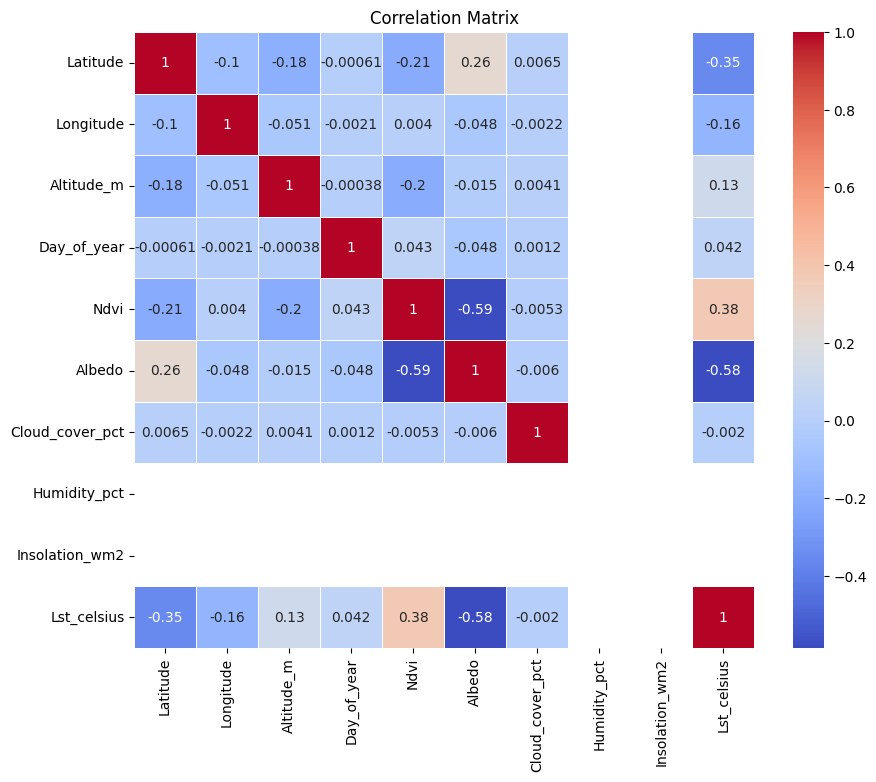

In [7]:
# corrélation entre les variables
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

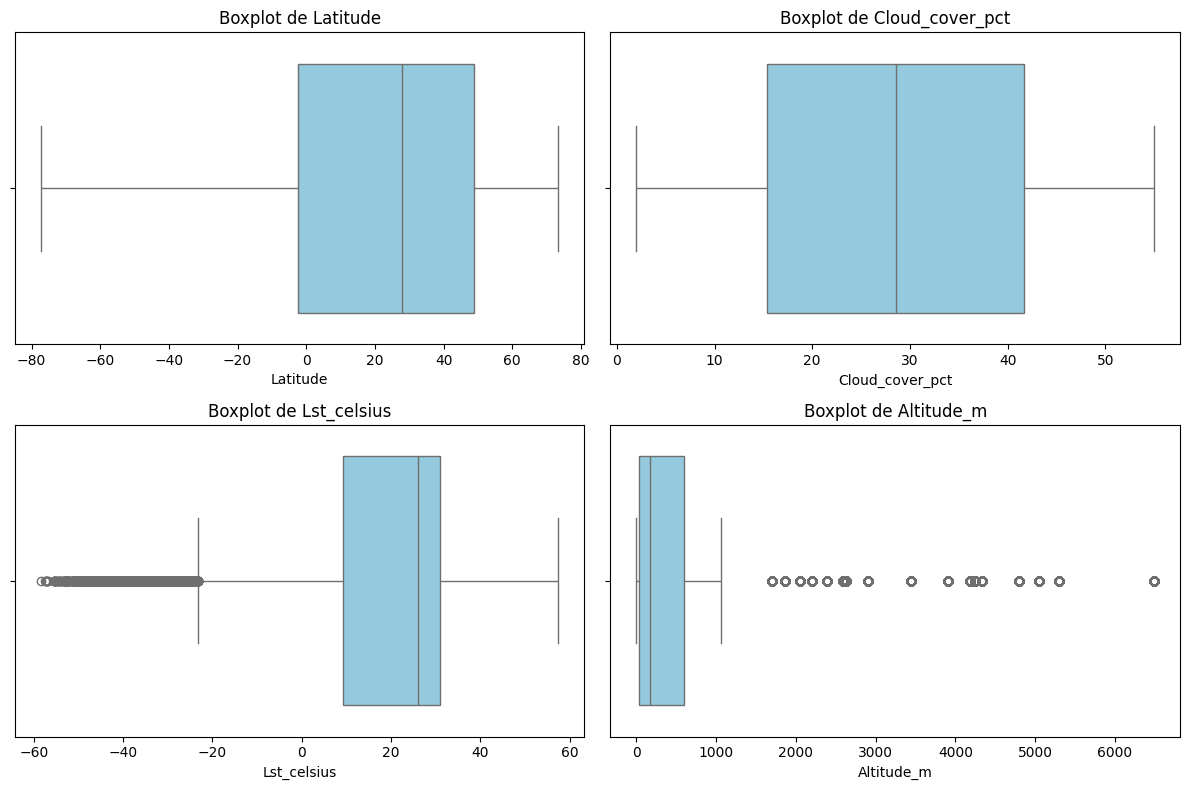

In [9]:
cols = ['Latitude', 'Cloud_cover_pct', 'Lst_celsius', 'Altitude_m']

plt.figure(figsize=(12, 8))
for i, col in enumerate(cols, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(data=df[col].dropna(), orient='h', color='skyblue')
    plt.title(f'Boxplot de {col}')
    plt.xlabel(col)

plt.tight_layout()
plt.show()

In [8]:
# Encodage cyclique de la date

df["day_sin"] = np.sin(2*np.pi*df["Day_of_year"]/365)

df["day_cos"] = np.cos(2*np.pi*df["Day_of_year"]/365)

df.drop(columns=["Day_of_year"], inplace=True)

### Modèle de régrssion corrigé suivant la logique phisique

In [10]:
# 2. Définition des features (X)
# Note : On inclut Lst_celsius car la température aide à définir le type de région
features = ['Latitude', 'Longitude', 'Altitude_m', 'Ndvi', 'Albedo', 
            'Cloud_cover_pct', 'Lst_celsius', 'day_sin', 'day_cos']
X = df[features]

# Encodage de la variable cible (Target)
le = LabelEncoder()
y = le.fit_transform(df['Region_Type'])

# Affichage des correspondances (utile pour vérification)
classes_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print("Mapping des classes :")
for region, encode_val in classes_mapping.items():
    print(f"{encode_val} -> {region}")

Mapping des classes :
0 -> Arid_Sandy_Desert
1 -> Coastal_Oceanic_Forest
2 -> Continental_Boreal_Taiga
3 -> Dense_Urban_Temperate
4 -> Equatorial_Wetland_Basin
5 -> High_Altitude_Alpine
6 -> Hyper_Arid_Desert_Floor
7 -> Intensive_Agricultural_Plain
8 -> Polar_Coastal_Desert
9 -> Polar_Ice_Sheet
10 -> Subtropical_Urban_Canopy
11 -> Tropical_Rainforest_Canopy


In [17]:
# 4. CONSTRUCTION DU PIPELINE 

# Prétraitement des variables numériques
preprocessor = ColumnTransformer(transformers=[
    ('num', Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), features)
])

# Pipeline final avec un RandomForest régularisé
clf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=150,          # On peut augmenter un peu le nombre d'arbres pour plus de stabilité
        max_depth=5,               # PROFONDEUR RÉDUITE (anti-overfitting majeur)
        min_samples_split=150,      # Il faut au moins 15 observations pour diviser un nœud
        min_samples_leaf=50,        # Il faut au moins 5 observations dans une feuille finale
        max_features='sqrt',       # Limite le nombre de variables regardées à chaque division
        class_weight='balanced',   # Toujours garder ceci pour le déséquilibre des classes
        random_state=42, 
        n_jobs=-1
    ))
])

In [ ]:
# 5. ÉVALUATION PAR VALIDATION CROISÉE

# StratifiedKFold préserve le ratio des classes dans chaque fold
from sklearn.model_selection import StratifiedKFold, cross_validate


skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Les métriques à observer pour la classification
scoring = ['accuracy', 'f1_macro']

print("Validation croisée en cours (cela peut prendre quelques secondes)...")
cv_results = cross_validate(clf_pipeline, X, y, cv=skf, scoring=scoring)

# Formatage des résultats sous forme de tableau 
df_cv = pd.DataFrame({
    'Accuracy': cv_results['test_accuracy'],
    'F1-Macro': cv_results['test_f1_macro']
}, index=[f"Fold {i+1}" for i in range(skf.n_splits)])

# Ajout de la moyenne et de l'écart-type
df_cv.loc['Mean'] = df_cv.iloc[:skf.n_splits].mean()
df_cv.loc['Std'] = df_cv.iloc[:skf.n_splits].std()

display(df_cv.round(4))

Validation croisée en cours (cela peut prendre quelques secondes)...


,Accuracy,F1-Macro
Fold 1,0.9994,0.9994
Fold 2,0.9985,0.9985
Fold 3,1.0000,1.0000
Fold 4,0.9997,0.9997
Fold 5,0.9985,0.9985
Mean,0.9992,0.9992
Std,0.0007,0.0007


In [19]:
# 6. ENTRAÎNEMENT FINAL ET SAUVEGARDE

# Entraînement sur la totalité du dataset
print("Entraînement final du modèle sur toutes les données...")
clf_pipeline.fit(X, y)

# Sauvegarde du Pipeline du Modèle
joblib.dump(clf_pipeline, "rf_region_classifier.pkl")

# Sauvegarde TRÈS IMPORTANTE de l'encodeur de labels (pour Streamlit)
joblib.dump(le, "label_encoder.pkl")

print("Succès ! Les fichiers 'rf_region_classifier.pkl' et 'label_encoder.pkl' ont été générés.")

Entraînement final du modèle sur toutes les données...
Succès ! Les fichiers 'rf_region_classifier.pkl' et 'label_encoder.pkl' ont été générés.
